In [3]:
%pip install pandas yfinance matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import yfinance as yf
import pandas as pd

# دانلود قیمت ۳ سهام از ۲ سال گذشته
tickers = ['AAPL', 'MSFT', 'GOOGL']
data = yf.download(tickers, start='2023-01-01', end='2024-12-31')['Close']

print(data.head(10))

[*********************100%***********************]  3 of 3 completed

Ticker            AAPL      GOOGL        MSFT
Date                                         
2023-01-03  122.982712  88.336693  232.948273
2023-01-04  124.251205  87.305832  222.758331
2023-01-05  122.933548  85.442368  216.156326
2023-01-06  127.456779  86.572334  218.703796
2023-01-09  127.977913  87.246361  220.833160
2023-01-10  128.548248  87.642838  222.515289
2023-01-11  131.262192  90.715607  229.243713
2023-01-12  131.183533  90.329025  231.907883
2023-01-13  132.510971  91.310333  232.607895
2023-01-17  133.671326  90.487633  233.696930


In [5]:
# محاسبه بازده روزانه
returns = data.pct_change().dropna()

print(returns.head(10))

Ticker          AAPL     GOOGL      MSFT
Date                                    
2023-01-04  0.010314 -0.011670 -0.043743
2023-01-05 -0.010605 -0.021344 -0.029638
2023-01-06  0.036794  0.013225  0.011785
2023-01-09  0.004089  0.007786  0.009736
2023-01-10  0.004457  0.004544  0.007617
2023-01-11  0.021112  0.035060  0.030238
2023-01-12 -0.000599 -0.004261  0.011622
2023-01-13  0.010119  0.010864  0.003018
2023-01-17  0.008757 -0.009010  0.004682
2023-01-18 -0.005370 -0.001862 -0.018889


<Figure size 1200x600 with 0 Axes>

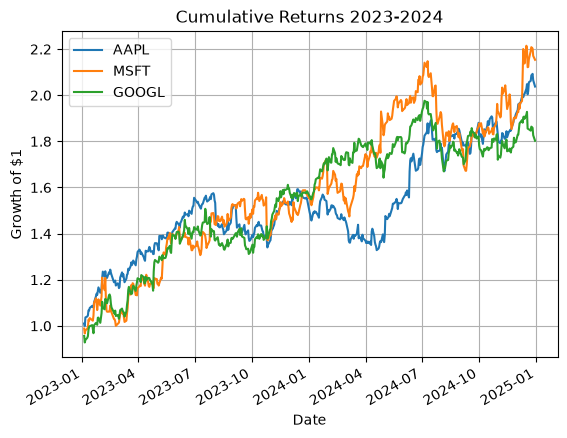

In [6]:
import matplotlib.pyplot as plt

# بازده تجمعی
cumulative = (1 + returns).cumprod()

plt.figure(figsize=(12, 6))
cumulative.plot()
plt.title('Cumulative Returns 2023-2024')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend(['AAPL', 'MSFT', 'GOOGL'])
plt.grid(True)
plt.show()

In [7]:
# آمار کلیدی
annual_return = returns.mean() * 252
annual_risk = returns.std() * (252 ** 0.5)

summary = pd.DataFrame({
    'بازده سالانه': annual_return,
    'ریسک سالانه': annual_risk,
    'شارپ (بدون نرخ بی‌ریسک)': annual_return / annual_risk
})

print(summary.round(3))

        بازده سالانه  ریسک سالانه  شارپ (بدون نرخ بی‌ریسک)
Ticker                                                    
AAPL           0.382        0.214                    1.786
GOOGL          0.430        0.292                    1.470
MSFT           0.323        0.227                    1.422


# تحلیل ریسک و بازده پرتفوی با Python

در این تحلیل، بازده و ریسک سه سهام بزرگ تکنولوژی را
برای سال‌های ۲۰۲۳ و ۲۰۲۴ بررسی می‌کنیم.

## داده‌ها
قیمت روزانه سهام Apple، Microsoft و Google از Yahoo Finance دریافت شده.